In [1]:
# !pip install torchvision

In [2]:
import os
import torch
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms
from PIL import Image

In [3]:
#image load => transform => dataset of all images
class ImageProcessor:
    def __init__(self,root_dir_path,transformation=None):
        self.root_dir_path = root_dir_path
        self.transformation = transformation


        #list of path for all images
        self.all_img_path = [
            os.path.join(root_dir_path, img)
            for img in os.listdir(root_dir_path)
]
    def __len__(self):
        return len(self.all_img_path)

    def __getitem__(self,idx):
        img_path = self.all_img_path[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformation:
            img = self.transformation(img)

        return img

In [4]:
root_dir_path = "./img_align_celeba"

transformation = transforms.Compose([
    transforms.CenterCrop(178), #178x256 => 178 x 178
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))   ]
)

In [5]:
#create dataset
dataset = ImageProcessor(root_dir_path,transformation)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [6]:
#create dataloader
dataloader = DataLoader(
    dataset,
    batch_size = 128,
    shuffle = True
)

# Generator Network

In [7]:
import torch.nn as nn
import torch.optim as optim 
import numpy as np

In [8]:
class Generator(nn.Module):
    def __init__(self,z_dim=100,img_channels=3): #3 is for rgb
        super(Generator,self).__init__()

        #fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim,256),#100 =>256
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.ReLU(),


            nn.Linear(1024,64*64* img_channels),
            nn.Tanh() #convert pixels to  [-1,1] for similar attribute as real img
            
        )
        
    def forward(self,z):
        img = self.model(z)
        img = img.view(img.size(0),3,64,64)
        return img

# Discriminator Network

In [9]:
class Discriminator(nn.Module):
    def __init__(self,img_channels=3):
        super(Discriminator,self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(), #4d tensor ==> 1d

            nn.Linear(img_channels*64*64,1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024,512),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(256,1),
            nn.Sigmoid() #prob of being real/fake
            
        )

    def forward(self,img):
        return self.model(img)

In [10]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002,betas=(0.5,0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [11]:
import torch
# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [12]:
generator = generator.to(device)
discriminator = discriminator.to(device)

In [16]:
def train(generator,discriminator,dataloader,epochs=10):
    for epoch in range(epochs):
        for i,imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size=real_imgs.size(0)

            #create real and fake img labels
            real_labels = torch.ones(batch_size,1).to(device)
            fake_labels = torch.zeros(batch_size,1).to(device)

            #Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size , 100).to(device))

            real_loss = GAN_loss(discriminator(real_imgs),real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()),fake_labels)

            d_loss = (real_loss + fake_loss)/2

            d_loss.backward()
            d_optimizer.step()


            #Train the Generator
            g_optimizer.zero_grad()
            g_loss = GAN_loss(discriminator(fake_imgs),real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i%50==0:
                print(f"for epoch:{epoch+1}/{epochs}... batch:{i+1}... G-loss:{g_loss}... D_loss:{d_loss}")

        save_generated_image(generator,epoch,device) #for each epochs

## Function to save all generated images

In [17]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_image(generator,epoch,device,num_imgs=8):
    z = torch.randn(num_imgs,100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid= torchvision.utils.make_grid(generated_imgs,nrow=4,normalize=True)

    #plotting
    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch:1/10... batch:1... G-loss:0.6823567152023315... D_loss:0.35227543115615845
for epoch:1/10... batch:51... G-loss:0.6043212413787842... D_loss:0.4714888334274292
for epoch:1/10... batch:101... G-loss:0.713544487953186... D_loss:0.3915391266345978
for epoch:1/10... batch:151... G-loss:0.5569931268692017... D_loss:0.7334355115890503
for epoch:1/10... batch:201... G-loss:1.0124809741973877... D_loss:0.32243722677230835
for epoch:1/10... batch:251... G-loss:0.9298874139785767... D_loss:0.40027403831481934
for epoch:1/10... batch:301... G-loss:0.6276315450668335... D_loss:0.29999345541000366
for epoch:1/10... batch:351... G-loss:0.9774603843688965... D_loss:0.3232544958591461
for epoch:1/10... batch:401... G-loss:0.933110237121582... D_loss:0.29151755571365356
for epoch:1/10... batch:451... G-loss:1.15853750705719... D_loss:0.36425668001174927
for epoch:1/10... batch:501... G-loss:0.8696792721748352... D_loss:0.31566137075424194
for epoch:1/10... batch:551... G-loss:0.97407120466232

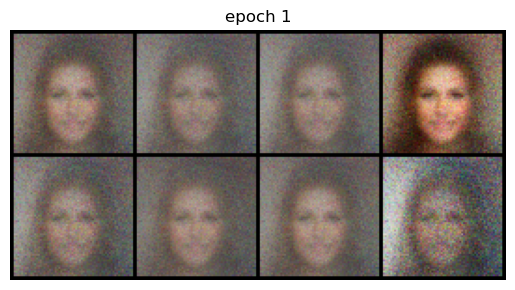

for epoch:2/10... batch:1... G-loss:4.051424503326416... D_loss:0.4132147431373596
for epoch:2/10... batch:51... G-loss:2.8364357948303223... D_loss:0.3354697525501251
for epoch:2/10... batch:101... G-loss:4.7286529541015625... D_loss:0.4042542278766632
for epoch:2/10... batch:151... G-loss:1.7401096820831299... D_loss:0.31724947690963745
for epoch:2/10... batch:201... G-loss:2.175326108932495... D_loss:0.2266821563243866
for epoch:2/10... batch:251... G-loss:2.164555549621582... D_loss:0.1988704949617386
for epoch:2/10... batch:301... G-loss:2.2773640155792236... D_loss:0.23038798570632935
for epoch:2/10... batch:351... G-loss:2.0951662063598633... D_loss:0.28906047344207764
for epoch:2/10... batch:401... G-loss:2.674178123474121... D_loss:0.3544738292694092
for epoch:2/10... batch:451... G-loss:2.130089044570923... D_loss:0.2423115223646164
for epoch:2/10... batch:501... G-loss:1.9738292694091797... D_loss:0.29701218008995056
for epoch:2/10... batch:551... G-loss:2.0410962104797363..

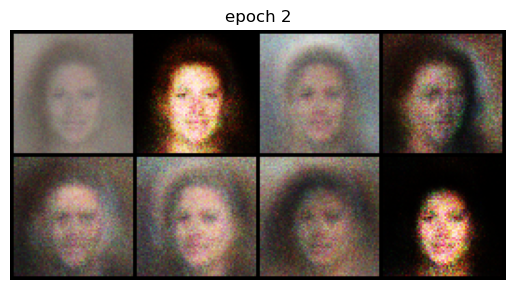

for epoch:3/10... batch:1... G-loss:2.181260108947754... D_loss:0.3411732316017151
for epoch:3/10... batch:51... G-loss:2.1552112102508545... D_loss:0.4192618727684021
for epoch:3/10... batch:101... G-loss:2.0890486240386963... D_loss:0.4047310948371887
for epoch:3/10... batch:151... G-loss:2.199054718017578... D_loss:0.34601444005966187
for epoch:3/10... batch:201... G-loss:1.7511990070343018... D_loss:0.5042235255241394
for epoch:3/10... batch:251... G-loss:1.9320416450500488... D_loss:0.2845621705055237
for epoch:3/10... batch:301... G-loss:1.9206651449203491... D_loss:0.4002465307712555
for epoch:3/10... batch:351... G-loss:2.939016819000244... D_loss:0.3387993276119232
for epoch:3/10... batch:401... G-loss:1.7802109718322754... D_loss:0.34420090913772583
for epoch:3/10... batch:451... G-loss:2.457890510559082... D_loss:0.38046717643737793
for epoch:3/10... batch:501... G-loss:1.6607247591018677... D_loss:0.5501378178596497
for epoch:3/10... batch:551... G-loss:2.0388617515563965..

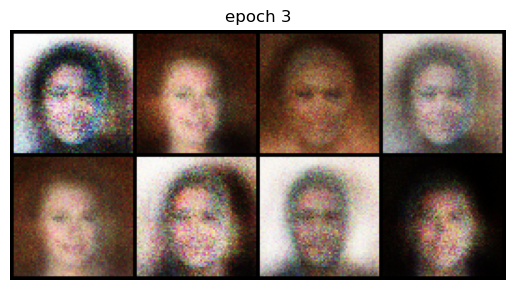

for epoch:4/10... batch:1... G-loss:1.549474835395813... D_loss:0.5275470614433289
for epoch:4/10... batch:51... G-loss:1.327826738357544... D_loss:0.5535301566123962
for epoch:4/10... batch:101... G-loss:1.6043283939361572... D_loss:0.529483437538147
for epoch:4/10... batch:151... G-loss:1.6840764284133911... D_loss:0.5449982285499573
for epoch:4/10... batch:201... G-loss:1.8282403945922852... D_loss:0.42458388209342957
for epoch:4/10... batch:251... G-loss:1.7757508754730225... D_loss:0.480904221534729
for epoch:4/10... batch:301... G-loss:1.713270664215088... D_loss:0.5198702216148376
for epoch:4/10... batch:351... G-loss:1.9519892930984497... D_loss:0.45893871784210205
for epoch:4/10... batch:401... G-loss:1.4727954864501953... D_loss:0.48255467414855957
for epoch:4/10... batch:451... G-loss:2.1336255073547363... D_loss:0.401547372341156
for epoch:4/10... batch:501... G-loss:1.7728840112686157... D_loss:0.3902793228626251
for epoch:4/10... batch:551... G-loss:1.9437494277954102... 

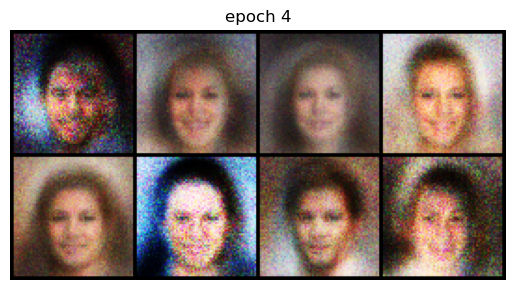

for epoch:5/10... batch:1... G-loss:1.8961726427078247... D_loss:0.4779871106147766
for epoch:5/10... batch:51... G-loss:1.1626683473587036... D_loss:0.5134141445159912
for epoch:5/10... batch:101... G-loss:1.6503121852874756... D_loss:0.43394532799720764
for epoch:5/10... batch:151... G-loss:2.1745071411132812... D_loss:0.4950263500213623
for epoch:5/10... batch:201... G-loss:1.6348158121109009... D_loss:0.43720877170562744
for epoch:5/10... batch:251... G-loss:1.547532558441162... D_loss:0.44950783252716064
for epoch:5/10... batch:301... G-loss:1.6750686168670654... D_loss:0.4532822072505951
for epoch:5/10... batch:351... G-loss:1.6085906028747559... D_loss:0.4303937554359436
for epoch:5/10... batch:401... G-loss:1.4692142009735107... D_loss:0.6546595096588135
for epoch:5/10... batch:451... G-loss:1.7622933387756348... D_loss:0.43128275871276855
for epoch:5/10... batch:501... G-loss:1.6089327335357666... D_loss:0.5263544917106628
for epoch:5/10... batch:551... G-loss:1.33087086677551

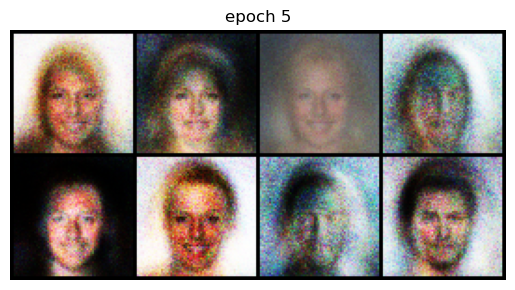

for epoch:6/10... batch:1... G-loss:2.1906580924987793... D_loss:0.5084494352340698
for epoch:6/10... batch:51... G-loss:1.5766723155975342... D_loss:0.5014464259147644
for epoch:6/10... batch:101... G-loss:1.7112151384353638... D_loss:0.5268627405166626
for epoch:6/10... batch:151... G-loss:1.7207062244415283... D_loss:0.5325213670730591
for epoch:6/10... batch:201... G-loss:1.2722446918487549... D_loss:0.5234140157699585
for epoch:6/10... batch:251... G-loss:1.5269017219543457... D_loss:0.46902763843536377
for epoch:6/10... batch:301... G-loss:1.7742397785186768... D_loss:0.41993460059165955
for epoch:6/10... batch:351... G-loss:1.5076855421066284... D_loss:0.48264771699905396
for epoch:6/10... batch:401... G-loss:1.6458144187927246... D_loss:0.5138057470321655
for epoch:6/10... batch:451... G-loss:1.4893866777420044... D_loss:0.5652045011520386
for epoch:6/10... batch:501... G-loss:1.4634133577346802... D_loss:0.571448028087616
for epoch:6/10... batch:551... G-loss:1.875005960464477

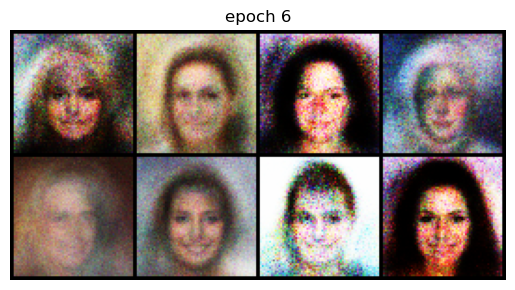

for epoch:7/10... batch:1... G-loss:1.6439461708068848... D_loss:0.4850490093231201
for epoch:7/10... batch:51... G-loss:1.270989179611206... D_loss:0.5250888466835022
for epoch:7/10... batch:101... G-loss:1.486720323562622... D_loss:0.5678339004516602
for epoch:7/10... batch:151... G-loss:1.5605276823043823... D_loss:0.5041780471801758
for epoch:7/10... batch:201... G-loss:1.6324586868286133... D_loss:0.519839346408844
for epoch:7/10... batch:251... G-loss:1.8953633308410645... D_loss:0.5152219533920288
for epoch:7/10... batch:301... G-loss:1.7101860046386719... D_loss:0.5584350824356079
for epoch:7/10... batch:351... G-loss:1.46931791305542... D_loss:0.49641260504722595
for epoch:7/10... batch:401... G-loss:1.492973804473877... D_loss:0.529030442237854
for epoch:7/10... batch:451... G-loss:1.598308801651001... D_loss:0.5123519897460938
for epoch:7/10... batch:501... G-loss:1.5950063467025757... D_loss:0.49845755100250244
for epoch:7/10... batch:551... G-loss:1.519160509109497... D_lo

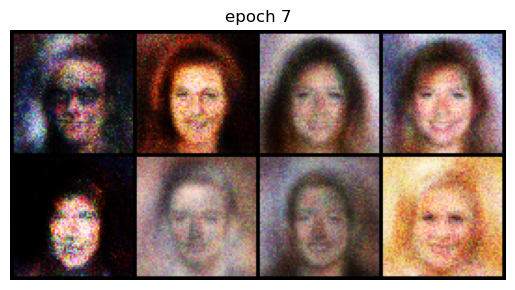

for epoch:8/10... batch:1... G-loss:1.3187237977981567... D_loss:0.5454256534576416
for epoch:8/10... batch:51... G-loss:1.3642005920410156... D_loss:0.5370191335678101
for epoch:8/10... batch:101... G-loss:1.4037067890167236... D_loss:0.5366339683532715
for epoch:8/10... batch:151... G-loss:1.3753117322921753... D_loss:0.5648998022079468
for epoch:8/10... batch:201... G-loss:1.331785798072815... D_loss:0.551315426826477
for epoch:8/10... batch:251... G-loss:1.4300462007522583... D_loss:0.5550215244293213
for epoch:8/10... batch:301... G-loss:1.474434494972229... D_loss:0.5609426498413086
for epoch:8/10... batch:351... G-loss:1.4331698417663574... D_loss:0.5110724568367004
for epoch:8/10... batch:401... G-loss:1.521143913269043... D_loss:0.5109262466430664
for epoch:8/10... batch:451... G-loss:1.385569453239441... D_loss:0.6015548706054688
for epoch:8/10... batch:501... G-loss:1.6308479309082031... D_loss:0.4860795736312866
for epoch:8/10... batch:551... G-loss:1.6138252019882202... D_

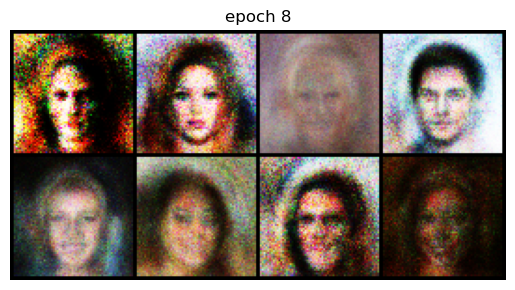

for epoch:9/10... batch:1... G-loss:1.3061798810958862... D_loss:0.5410634875297546
for epoch:9/10... batch:51... G-loss:1.3845856189727783... D_loss:0.5582787990570068
for epoch:9/10... batch:101... G-loss:1.4577430486679077... D_loss:0.5760384798049927
for epoch:9/10... batch:151... G-loss:1.6635361909866333... D_loss:0.5658010840415955
for epoch:9/10... batch:201... G-loss:1.3792507648468018... D_loss:0.5632769465446472
for epoch:9/10... batch:251... G-loss:1.2158230543136597... D_loss:0.5814418792724609
for epoch:9/10... batch:301... G-loss:1.2855851650238037... D_loss:0.5063197016716003
for epoch:9/10... batch:351... G-loss:1.4112968444824219... D_loss:0.5485814809799194
for epoch:9/10... batch:401... G-loss:1.2761646509170532... D_loss:0.6083338856697083
for epoch:9/10... batch:451... G-loss:1.2792292833328247... D_loss:0.5900371074676514
for epoch:9/10... batch:501... G-loss:1.4079525470733643... D_loss:0.5659835338592529
for epoch:9/10... batch:551... G-loss:1.615788221359253..

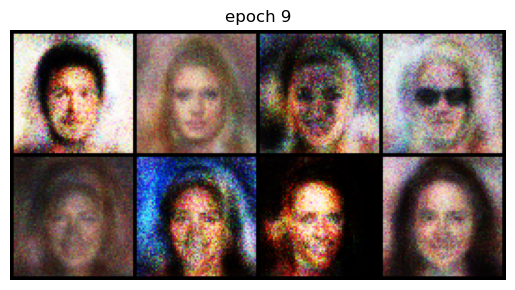

for epoch:10/10... batch:1... G-loss:1.23878014087677... D_loss:0.6257823705673218
for epoch:10/10... batch:51... G-loss:1.3835546970367432... D_loss:0.5553680658340454
for epoch:10/10... batch:101... G-loss:1.3873196840286255... D_loss:0.5589402914047241


In [ ]:
train(generator,discriminator,dataloader,epochs=10)